# 3주차 답안

미션 1~7의 정답 코드와 해설입니다. 학생용 노트북을 먼저 끝까지 풀어본 다음에 여세요.

이번 주의 고비는 미션 5입니다. 웨이퍼 한 장 60줄을 1줄로 줄입니다.
줄여서 무엇을 얻고 무엇을 잃는지가 오늘의 질문입니다.

- 코드가 글자까지 같을 필요는 없습니다. 자가진단이 통과하고 숫자가 맞으면 맞은 답입니다.
- 미션마다 아래에 왜 이렇게 푸는지와 자주 나오는 실수를 적어두었습니다. 코드보다 이쪽을 읽으세요.
- 맨 아래 기준값으로 본인 숫자를 대조하고, 미션 8은 자가점검 표로 확인하세요.

In [ ]:
# 이 셀은 그대로 실행하세요.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

_have = {f.name for f in fm.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    if _f in _have:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

DATA = Path('../../data/etch_fdc')   # 폴더를 옮겼다면 이 줄만 고치세요

def check(name, cond, hint=''):
    if cond:
        print('[통과] ' + name)
    else:
        print('[실패] ' + name + (('  ->  ' + str(hint)) if hint else ''))

print('폰트:', plt.rcParams['font.family'][0], '| 데이터 폴더:', DATA.exists())

폰트: Malgun Gothic | 데이터 폴더: True


---

## 미션 1 · 트레이스 열어보기

In [ ]:
tr = pd.read_csv(DATA / 'traces.csv', encoding='utf-8-sig')
wi = pd.read_csv(DATA / 'wafer_info.csv', encoding='utf-8-sig', parse_dates=['timestamp'])

print('traces    :', tr.shape)
print('wafer_info:', wi.shape)
print('웨이퍼 수 :', tr.wafer_id.nunique())
print('장당 행 수:', len(tr) // tr.wafer_id.nunique())

fault_counts = wi.fault_type.value_counts()
print()
print(fault_counts.to_string())

traces    : (24000, 11)
wafer_info: (400, 6)
웨이퍼 수 : 400
장당 행 수: 60

fault_type
NORMAL            316
RF_UNSTABLE        30
PRESSURE_DRIFT     30
GAS_LEAK           24


지금까지와 데이터 모양이 다릅니다. 한 행이 웨이퍼 한 장이 아니라 웨이퍼 한 장의
1초짜리 기록입니다. 24000 = 400장 × 60초라는 계산을 직접 확인하세요.

이 구조를 잡고 가지 않으면 미션 5의 `groupby('wafer_id')` 가 왜 필요한지 이해되지 않습니다.

---

## 미션 2 · 웨이퍼 한 장을 눈으로 보기

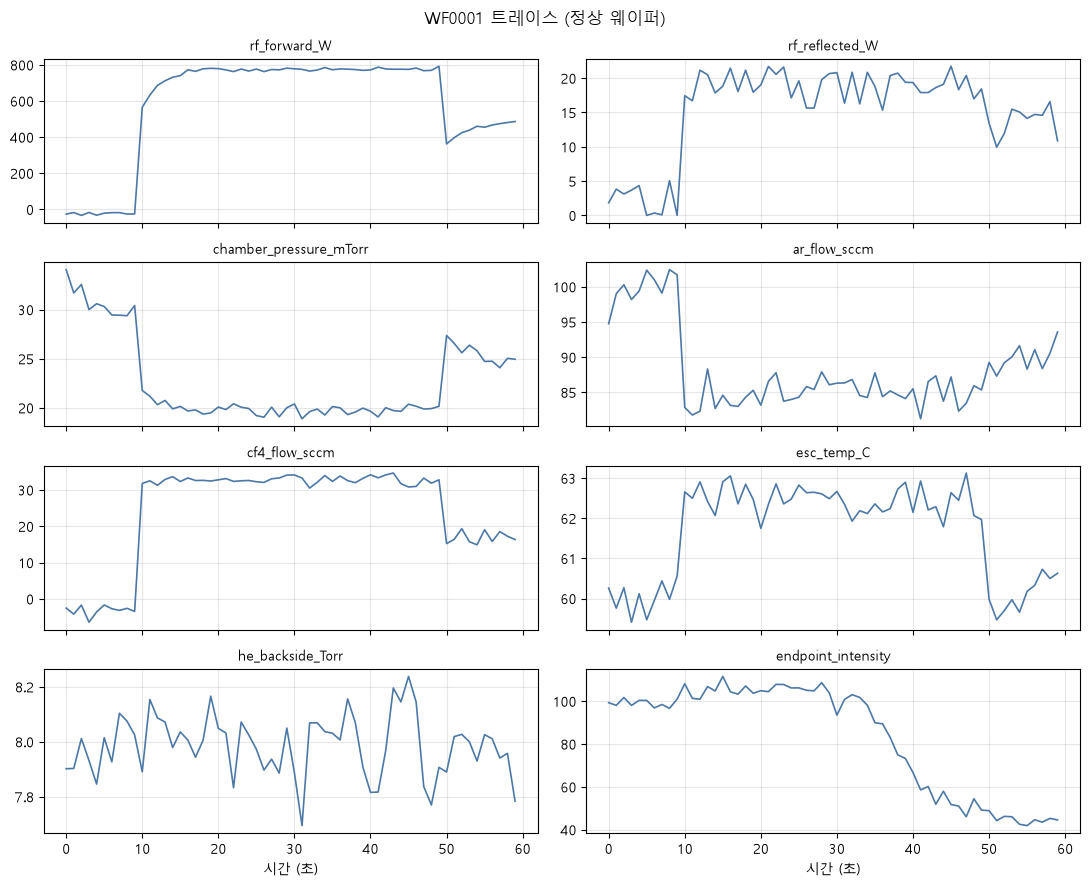

0~9초 Stabilize, 10~49초 MainEtch, 50~59초 Overetch
RF 전력이 10초에 켜지고, 종점 신호가 35초 근처에서 꺾입니다.


In [ ]:
one = tr[tr.wafer_id == 'WF0001']
SENSORS = ['rf_forward_W', 'rf_reflected_W', 'chamber_pressure_mTorr', 'ar_flow_sccm','cf4_flow_sccm', 'esc_temp_C', 'he_backside_Torr', 'endpoint_intensity']
# 서브 플롯 8개 (4행 x 2열)
fig, axes = plt.subplots(4, 2, figsize=(11, 9), sharex=True)

# axes.ravel() : 4*2 배열형태를 1차원으로 펼침 각각의 플롯이 ax로 매칭
for ax, s in zip(axes.ravel(), SENSORS):
    ax.plot(one.t_sec, one[s], linewidth=1.2, color='#4C78A8')
    ax.set_title(s, fontsize=10)
    ax.grid(alpha=.3)
for ax in axes[-1]:
    ax.set_xlabel('시간 (초)')
fig.suptitle('WF0001 트레이스 (정상 웨이퍼)')
plt.tight_layout()
plt.show()

print('0~9초 Stabilize, 10~49초 MainEtch, 50~59초 Overetch')
print('RF 전력이 10초에 켜지고, 종점 신호가 35초 근처에서 꺾입니다.')

시계열은 표보다 그림이 먼저입니다. 숫자를 요약하기 전에 일단 그려야 합니다.

subplot 8칸이 처음이면 `axes.ravel()` 을 눈여겨보세요. `plt.subplots(4, 2)` 가 돌려주는
4×2 배열을 8칸짜리 한 줄로 펴 주는 함수입니다. 그래야 센서 목록과 `zip` 으로 묶입니다.

---

## 미션 3 · 스텝 구조 파악하기

In [ ]:
step_len = one.groupby('step', sort=False).size()
print('스텝별 초:')
print(step_len.to_string())

by_step = tr.groupby('step')[SENSORS].mean().round(2)
print()
print(by_step.to_string())

print()
print('Stabilize 에는 RF가 0에 가깝고 CF4도 안 흘립니다.')
print('MainEtch 에서 RF 800W, CF4 40sccm 이 들어갑니다.')

스텝별 초:
step
Stabilize    10
MainEtch     40
Overetch     10

           rf_forward_W  rf_reflected_W  chamber_pressure_mTorr  ar_flow_sccm  cf4_flow_sccm  esc_temp_C  he_backside_Torr  endpoint_intensity
step                                                                                                                                          
MainEtch         784.71           19.32                   20.25         79.89          39.47       64.56               8.0               84.50
Overetch         462.42           12.77                   25.90         88.63          19.62       62.05               8.0               45.01
Stabilize         -0.15            3.00                   31.05         98.46          -0.12       62.06               8.0              100.00

Stabilize 에는 RF가 0에 가깝고 CF4도 안 흘립니다.
MainEtch 에서 RF 800W, CF4 40sccm 이 들어갑니다.


스텝이 왜 나뉘어 있는지는 공정을 알면 자연스럽습니다. 가스가 안정되기 전에 RF를 켜면
플라즈마가 제대로 붙지 않습니다. 그래서 Stabilize 에서 가스를 흘려 압력을 잡고,
MainEtch 에서 RF를 넣고, Overetch 로 마무리합니다.

이상은 대부분 MainEtch 에 나타납니다. 미션 5에서 이 구간만 골라 쓰는 이유입니다.

---

## 미션 4 · 정상과 이상을 겹쳐 그리기

{'RF_UNSTABLE': 'WF0017', 'PRESSURE_DRIFT': 'WF0026', 'GAS_LEAK': 'WF0001'}


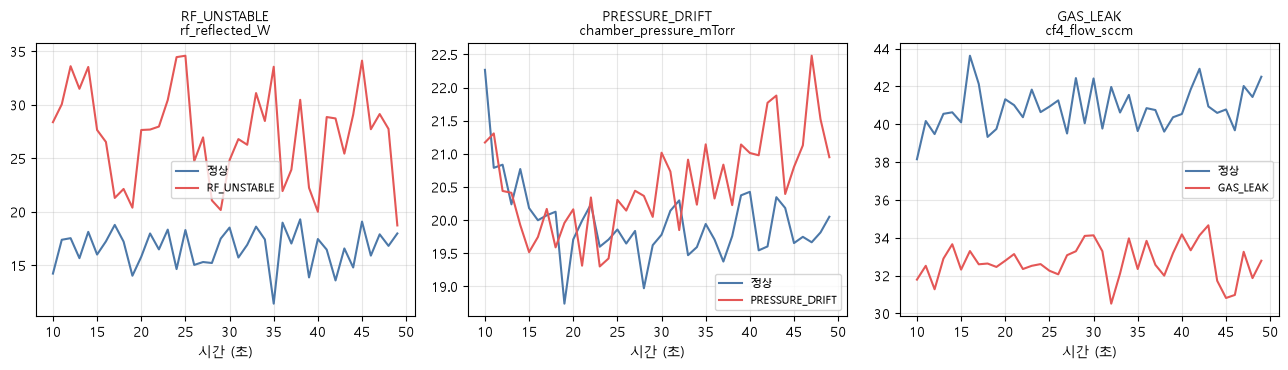

In [ ]:
normal_id = wi[wi.fault_type == 'NORMAL'].wafer_id.iloc[0]
picks = {f: wi[wi.fault_type == f].wafer_id.iloc[0]
         for f in ['RF_UNSTABLE', 'PRESSURE_DRIFT', 'GAS_LEAK']}
print(picks)

TARGET = {'RF_UNSTABLE': 'rf_reflected_W',
          'PRESSURE_DRIFT': 'chamber_pressure_mTorr',
          'GAS_LEAK': 'cf4_flow_sccm'}

main = tr[tr.step == 'MainEtch']
base = main[main.wafer_id == normal_id]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (f, wid) in zip(axes, picks.items()):
    s = TARGET[f]
    g = main[main.wafer_id == wid]
    ax.plot(base.t_sec, base[s], label='정상', color='#4C78A8', linewidth=1.5)
    ax.plot(g.t_sec, g[s], label=f, color='#E45756', linewidth=1.5)
    ax.set_title(f + '\n' + s, fontsize=10)
    ax.set_xlabel('시간 (초)')
    ax.legend(fontsize=8)
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

겹쳐 그리는 것이 요령입니다. 정상과 이상을 따로 그리면 y축 범위가 달라져서
차이가 눈에 안 보입니다. 이 미션에서 가장 흔한 실수입니다.

GAS_LEAK 그림을 자세히 보세요. 나머지 둘과 달리 차이가 작습니다.
이 관찰이 미션 7과 다음 주 결과로 이어집니다.

---

## 미션 5 · 웨이퍼 한 장을 한 줄로 줄이기

In [ ]:
main = tr[tr.step == 'MainEtch']
feat = main.groupby('wafer_id')[SENSORS].agg(['mean', 'std', 'min', 'max'])
feat.columns = ['_'.join(c) for c in feat.columns]
print('특징 행렬:', feat.shape)
print(feat.iloc[:3, :4].round(3).to_string())

특징 행렬: (400, 32)
          rf_forward_W_mean  rf_forward_W_std  rf_forward_W_min  rf_forward_W_max
wafer_id                                                                         
WF0001              760.527            42.955            565.52            792.67
WF0002              780.846            41.172            587.76            805.75
WF0003              817.287            39.161            645.77            847.43


60줄을 1줄로 줄이는 것이 이번 주의 핵심 작업입니다. 무엇을 잃는지 생각해 보세요.

**순서 정보가 통째로 사라집니다.** 평균과 표준편차가 똑같은데 모양은 전혀 다른 두 트레이스를
얼마든지 만들 수 있습니다. 처음부터 높다가 내려온 것과, 낮다가 끝에서 튄 것을
이 특징들은 구분하지 못합니다.

그래서 요약 통계만으로 부족할 때 미션 6 같은 특징을 따로 만들게 됩니다.

---

## 미션 6 · 기울기라는 특징 만들기

In [ ]:
slope = main.groupby('wafer_id').apply(
    lambda g: np.polyfit(g.t_sec, g.chamber_pressure_mTorr, 1)[0])
feat['pressure_slope'] = slope
data = feat.reset_index().merge(wi, on='wafer_id')
print('결합:', data.shape)

print()
print('이상 유형별 압력 기울기 평균 (mTorr/초)')
print(data.groupby('fault_type').pressure_slope.mean().round(4).to_string())
print()
print('PRESSURE_DRIFT 만 확연히 큽니다. 나머지는 0 근처입니다.')

결합: (400, 39)

이상 유형별 압력 기울기 평균 (mTorr/초)
fault_type
GAS_LEAK         -0.0222
NORMAL           -0.0236
PRESSURE_DRIFT    0.0311
RF_UNSTABLE      -0.0238

PRESSURE_DRIFT 만 확연히 큽니다. 나머지는 0 근처입니다.


특징 공학이 왜 필요한지 보여주는 자리입니다.

압력이 서서히 올라가는 이상은 평균으로는 절대 잡히지 않습니다. 앞에서 낮고 뒤에서 높으면
평균은 정상과 같아지기 때문입니다. 기울기는 그 방향을 담습니다.

`np.polyfit(x, y, 1)[0]` 이 1차 직선의 기울기입니다. 다음 주에 이 `pressure_slope` 가
모델 중요도 1위로 나옵니다. 직접 만든 특징이 원본 센서 값을 이깁니다.

---

## 미션 7 · 어떤 특징이 어떤 이상을 잡는가

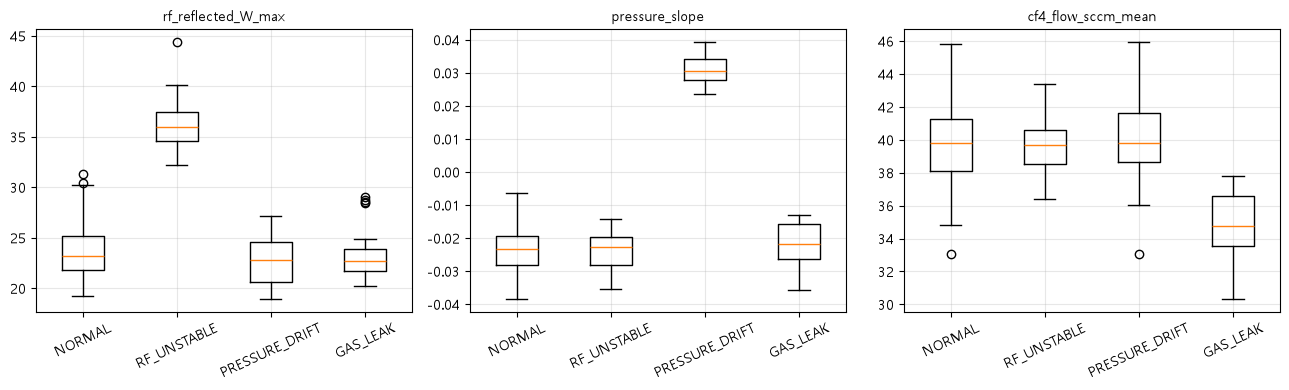

                rf_reflected_W_max  pressure_slope  cf4_flow_sccm_mean
fault_type                                                            
GAS_LEAK                    23.516          -0.022              34.868
NORMAL                      23.519          -0.024              39.760
PRESSURE_DRIFT              22.711           0.031              40.001
RF_UNSTABLE                 36.144          -0.024              39.555

CF4 평균은 정상 40 근처, GAS_LEAK 35 근처로 차이가 작습니다.
웨이퍼마다 정상 범위의 편차가 있어서 상자가 많이 겹칩니다.
다음 주에 이 유형만 잘 안 잡히는 걸 보게 됩니다.


In [ ]:
PICK = ['rf_reflected_W_max', 'pressure_slope', 'cf4_flow_sccm_mean']
ORDER = ['NORMAL', 'RF_UNSTABLE', 'PRESSURE_DRIFT', 'GAS_LEAK']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, PICK):
    ax.boxplot([data.loc[data.fault_type == f, c] for f in ORDER], tick_labels=ORDER)
        '''
        sns.boxplot(data=data, x='fault_type', y=PICK[0], order=ORDER, ax=axes[0])
        sns.boxplot(data=data, x='fault_type', y=PICK[1], order=ORDER, ax=axes[1])
        sns.boxplot(data=data, x='fault_type', y=PICK[2], order=ORDER, ax=axes[2])
        '''
    ax.set_title(c, fontsize=10)
    ax.tick_params(axis='x', rotation=25)
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

summary = data.groupby('fault_type')[PICK].mean().round(3)
print(summary.to_string())
print()
print('CF4 평균은 정상 40 근처, GAS_LEAK 35 근처로 차이가 작습니다.')
print('웨이퍼마다 정상 범위의 편차가 있어서 상자가 많이 겹칩니다.')
print('다음 주에 이 유형만 잘 안 잡히는 걸 보게 됩니다.')

GAS_LEAK 을 눈여겨보세요. CF4 유량 평균이 정상 40 근처, GAS_LEAK 35 근처로 차이가
작고 상자가 크게 겹칩니다. 웨이퍼마다 정상 범위의 편차가 있기 때문입니다.

다음 주에 이 유형만 재현율이 0.43으로 떨어집니다. 모델이 못 만들어진 것이 아니라
여기 있는 이 겹침이 원인입니다. 지금 그림을 기억해 두세요.

---

## 기준값

```
미션 1  traces (24000, 11), wafer_info (400, 6)
        NORMAL 316 / RF_UNSTABLE 30 / PRESSURE_DRIFT 30 / GAS_LEAK 24
미션 3  Stabilize 10초 / MainEtch 40초 / Overetch 10초
미션 5  특징 행렬 (400, 32)
미션 6  압력 기울기 평균  PRESSURE_DRIFT 만 +0.03 대, 나머지는 -0.02 근처
미션 7  rf_reflected_W_max  RF_UNSTABLE 이 최대
        cf4_flow_sccm_mean  GAS_LEAK 이 최소, 다만 정상과 많이 겹침
```

## 미션 8 자가점검

| 항목 | 답안에 들어가야 할 것 | 자주 나오는 부족한 답 |
|---|---|---|
| 1 데이터 차이 | 60줄 = 1초 × 60, 시계열이라는 말 | 그냥 크다고만 씀 |
| 2 잃는 정보 | 순서, 모양, 튀는 시점 | 잃는 것이 없다고 씀 |
| 3 구간 선택 | RF가 꺼진 구간에는 정보가 없다 | 그냥 길어서라고 씀 |
| 4 기울기 | 평균은 방향을 담지 못한다 | 기울기가 더 정확해서라고만 씀 |
| 5 난이도 | GAS_LEAK, 박스플롯 겹침을 근거로 | 근거 없이 찍음 |
| 6 놓칠 이상 | 순간 스파이크, 센서 간 관계 붕괴 | 한 가지만 쓰거나 형식적 |

6번에서 순간적인 스파이크를 짚었다면 잘 쓴 것입니다.
평균과 표준편차로는 1초짜리 이상을 잡을 수 없습니다.